<a href="https://colab.research.google.com/github/aarav06-bit/CS131_release/blob/master/spring_2026/final_project_nanomat/1_Data_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install abtem ase -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.7/376.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 62.3 MB/s eta 0:00:00


In [4]:
import matplotlib.pyplot as plt

from ase.build import bulk

from abtem import PlaneWave
from abtem.potentials.iam import Potential

# Create FCC gold crystal
atoms = bulk('Au', 'fcc', a=4.08)

# Repeat unit cell to create larger crystal
atoms = atoms.repeat((10,10,3))

# Create electron plane wave (200 keV TEM beam)
wave = PlaneWave(
    energy=200e3
)


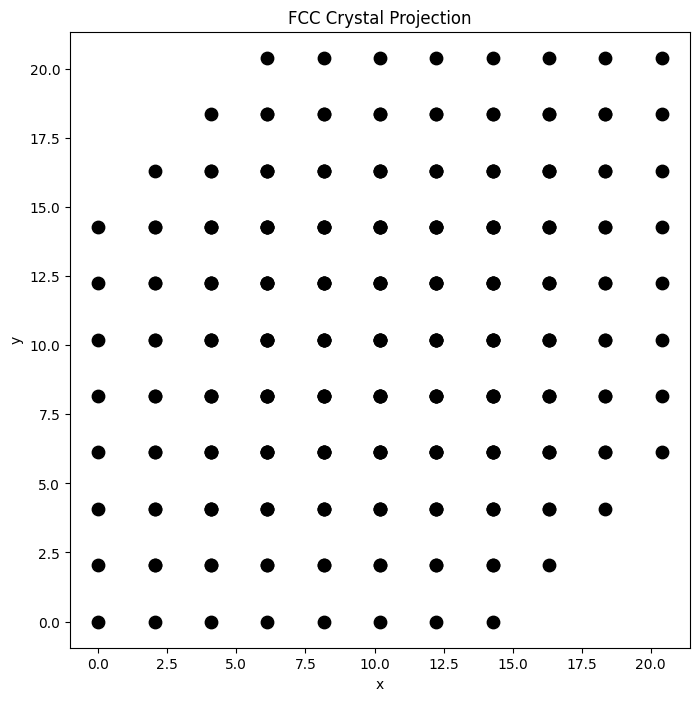

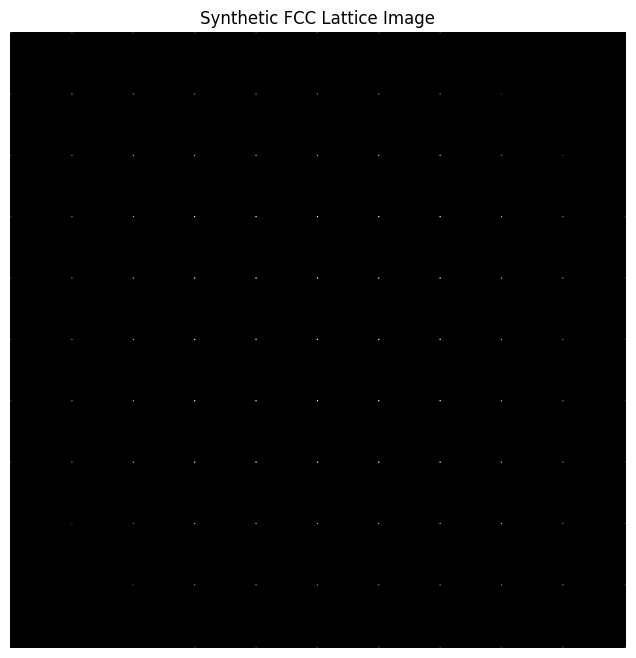

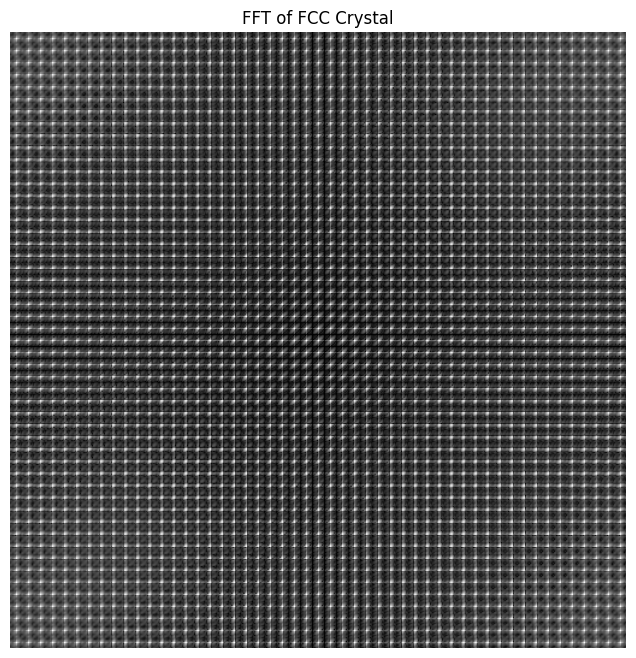

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from ase.build import bulk

# =========================
# CREATE FCC GOLD CRYSTAL
# =========================

atoms = bulk('Au', 'fcc', a=4.08)

# Repeat unit cell
atoms = atoms.repeat((8,8,4))

# =========================
# EXTRACT ATOMIC POSITIONS
# =========================

positions = atoms.get_positions()

x = positions[:,0]
y = positions[:,1]
z = positions[:,2]

# =========================
# PROJECT TO 2D
# =========================

# Simulate viewing crystal along z-axis
# by plotting x-y positions only

plt.figure(figsize=(8,8))

plt.scatter(
    x,
    y,
    s=80,
    c='black'
)

plt.title("FCC Crystal Projection")
plt.xlabel("x")
plt.ylabel("y")
plt.axis('equal')

plt.show()

# =========================
# CREATE IMAGE GRID
# =========================

grid_size = 512

image = np.zeros((grid_size, grid_size))

# Normalize coordinates
x_norm = (x - x.min()) / (x.max() - x.min())
y_norm = (y - y.min()) / (y.max() - y.min())

# Convert to pixel coordinates
x_pix = (x_norm * (grid_size - 1)).astype(int)
y_pix = (y_norm * (grid_size - 1)).astype(int)

# Place atomic points
for xp, yp in zip(x_pix, y_pix):
    image[yp, xp] += 1

# =========================
# DISPLAY SYNTHETIC LATTICE IMAGE
# =========================

plt.figure(figsize=(8,8))

plt.imshow(image, cmap='gray')

plt.title("Synthetic FCC Lattice Image")
plt.axis('off')

plt.show()

# =========================
# COMPUTE FFT
# =========================

fft = np.fft.fftshift(np.fft.fft2(image))

magnitude = np.log(np.abs(fft) + 1)

# =========================
# DISPLAY FFT
# =========================

plt.figure(figsize=(8,8))

plt.imshow(magnitude, cmap='gray')

plt.title("FFT of FCC Crystal")
plt.axis('off')

plt.show()

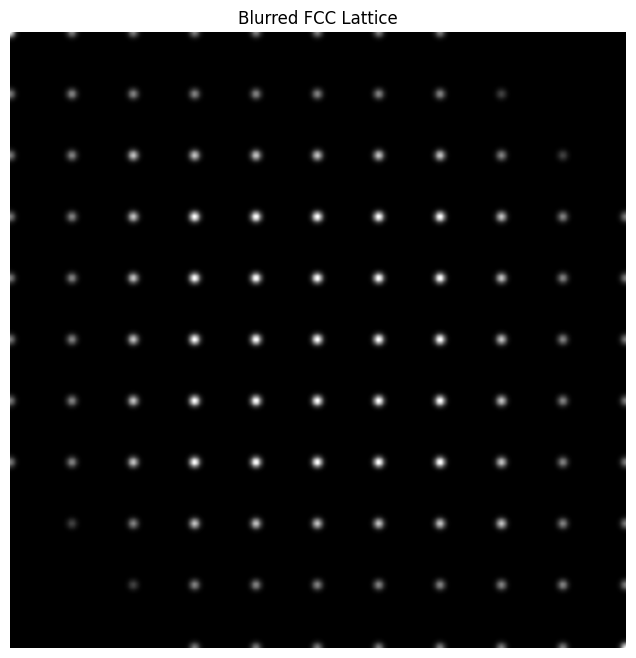

In [8]:
from scipy.ndimage import gaussian_filter

# Blur the lattice image
blurred = gaussian_filter(image, sigma=3)

# Display blurred image
plt.figure(figsize=(8,8))

plt.imshow(blurred, cmap='gray')

plt.title("Blurred FCC Lattice")
plt.axis('off')

plt.show()